In [12]:
# Install required libraries (usually already available in Colab)
!pip install scikit-learn pandas matplotlib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [13]:
# Load the Iris dataset directly from sklearn
iris = load_iris()

# Convert to DataFrame for better understanding
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'})

# Display the first 5 rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Iris-setosa
1,4.9,3.0,1.4,0.2,0,Iris-setosa
2,4.7,3.2,1.3,0.2,0,Iris-setosa
3,4.6,3.1,1.5,0.2,0,Iris-setosa
4,5.0,3.6,1.4,0.2,0,Iris-setosa


In [14]:
# Check basic information
print("🔍 Dataset Info:")
print(df.info())

# Check for missing values
print("\n❓ Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\n📈 Summary Statistics:\n", df.describe())

# Check class distribution
print("\n🌸 Class Distribution:\n", df['species'].value_counts())


🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

❓ Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

📈 Summary Statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435

In [15]:
# Features and target
X = df[iris.feature_names]   # Independent variables
y = df['target']             # Dependent variable

# No missing values or categorical encoding needed since data is clean

# Split into training and testing data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Training Set Shape:", X_train.shape)
print("✅ Testing Set Shape:", X_test.shape)


✅ Training Set Shape: (120, 4)
✅ Testing Set Shape: (30, 4)


In [16]:
# Create Decision Tree Classifier
clf = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=3,        # limits tree depth to avoid overfitting
    random_state=42
)

# Train (fit) the model
clf.fit(X_train, y_train)
print("🌟 Model Training Completed!")


🌟 Model Training Completed!


In [17]:
# Predict on test data
y_pred = clf.predict(X_test)

# Display some predictions
print("🔮 Sample Predictions:", y_pred[:10])
print("🎯 Actual Labels:     ", y_test.values[:10])


🔮 Sample Predictions: [0 2 1 1 0 1 0 0 2 1]
🎯 Actual Labels:      [0 2 1 1 0 1 0 0 2 1]


In [18]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("✅ Model Accuracy: {:.2f}%".format(accuracy * 100))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\n📋 Classification Report:\n", cr)


✅ Model Accuracy: 96.67%

📊 Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

📋 Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


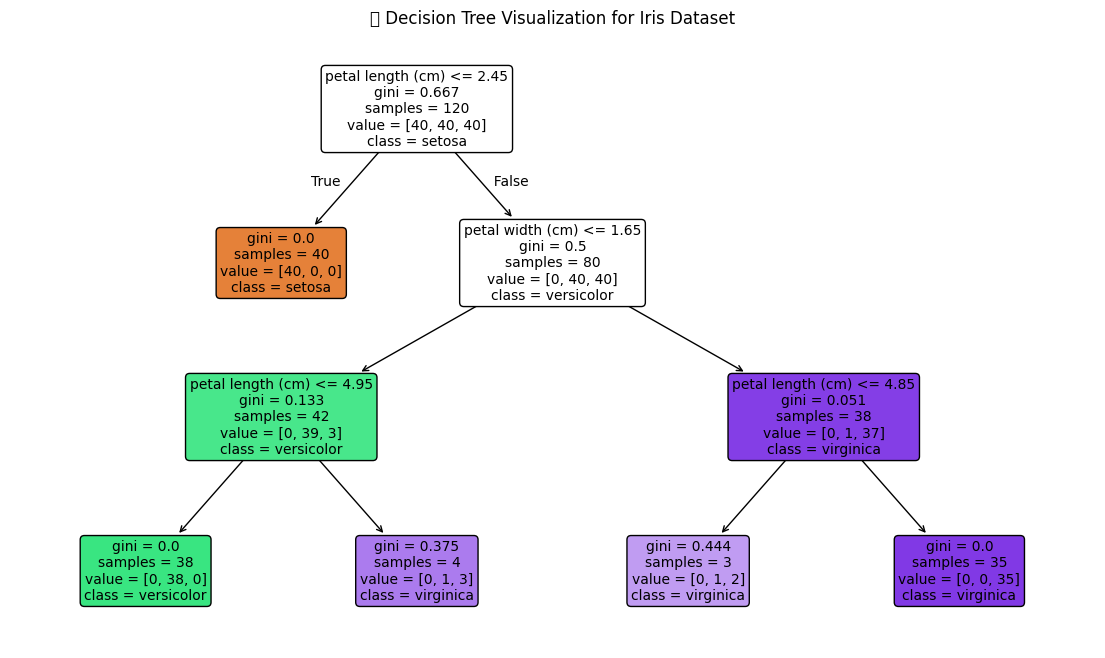

In [19]:
plt.figure(figsize=(14,8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("🌿 Decision Tree Visualization for Iris Dataset")
plt.show()


🌟 Feature Importances:
 petal length (cm)    0.579077
petal width (cm)     0.420923
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


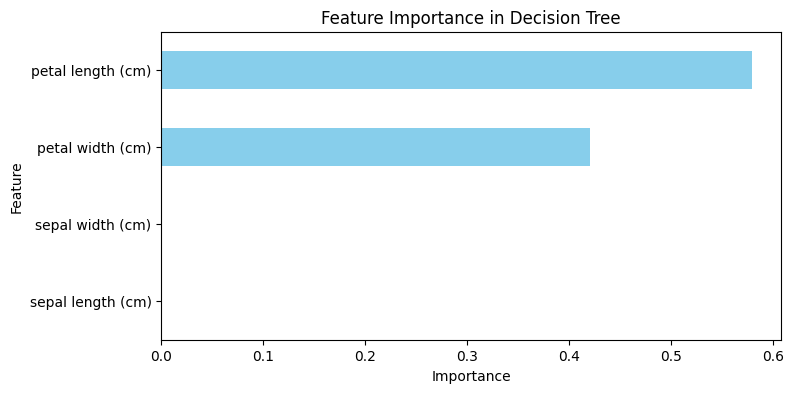

In [20]:
# Show how important each feature is in the classification
feature_importance = pd.Series(clf.feature_importances_, index=iris.feature_names)
print("🌟 Feature Importances:\n", feature_importance.sort_values(ascending=False))

# Plot feature importance
feature_importance.sort_values().plot(kind='barh', color='skyblue', figsize=(8,4))
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [21]:
print("✅ Final Conclusion:")
print(f"The Decision Tree Classifier achieved an accuracy of {accuracy * 100:.2f}% on test data.")
print("It shows that decision trees can effectively classify Iris flower species based on sepal and petal measurements.")


✅ Final Conclusion:
The Decision Tree Classifier achieved an accuracy of 96.67% on test data.
It shows that decision trees can effectively classify Iris flower species based on sepal and petal measurements.
